"""
Name: Module 6 Academic Success.py
Assignment 3 and 4 - logit regression
"""

In [1]:
# 
from statsmodels.discrete.discrete_model import MNLogit
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from scipy.stats import chi2
import os

# Find CSP571 folder by walking up from cwd
cwd = os.path.abspath(os.getcwd())
search_dir = cwd
base_dir = None
for _ in range(5):
    candidate = os.path.join(search_dir, "CSP571")
    if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "raw", "Utility.py")):
        base_dir = candidate
        break
    search_dir = os.path.dirname(search_dir)

if base_dir is None:
    raise FileNotFoundError("Could not locate CSP571/raw/Utility.py from current working directory.")

sys.path.append(os.path.join(base_dir, "raw")) 
import Utility

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format



In [2]:
face = pandas.read_csv(r'data\Face.csv')

face["IS_NOSE"] = (face["feature"].astype(int) == 3).astype(int)
face.drop(columns=["feature"], inplace=True)


Optimization terminated successfully.
         Current function value: 0.508368
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                IS_NOSE   No. Observations:                  129
Model:                          Logit   Df Residuals:                      126
Method:                           MLE   Df Model:                            2
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                 0.07810
Time:                        14:16:04   Log-Likelihood:                -65.580
converged:                       True   LL-Null:                       -71.135
Covariance Type:            nonrobust   LLR p-value:                  0.003865
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2629      0.226     -5.593      0.000      -1.706      -0.820
horizontal -1.304e-17      0.

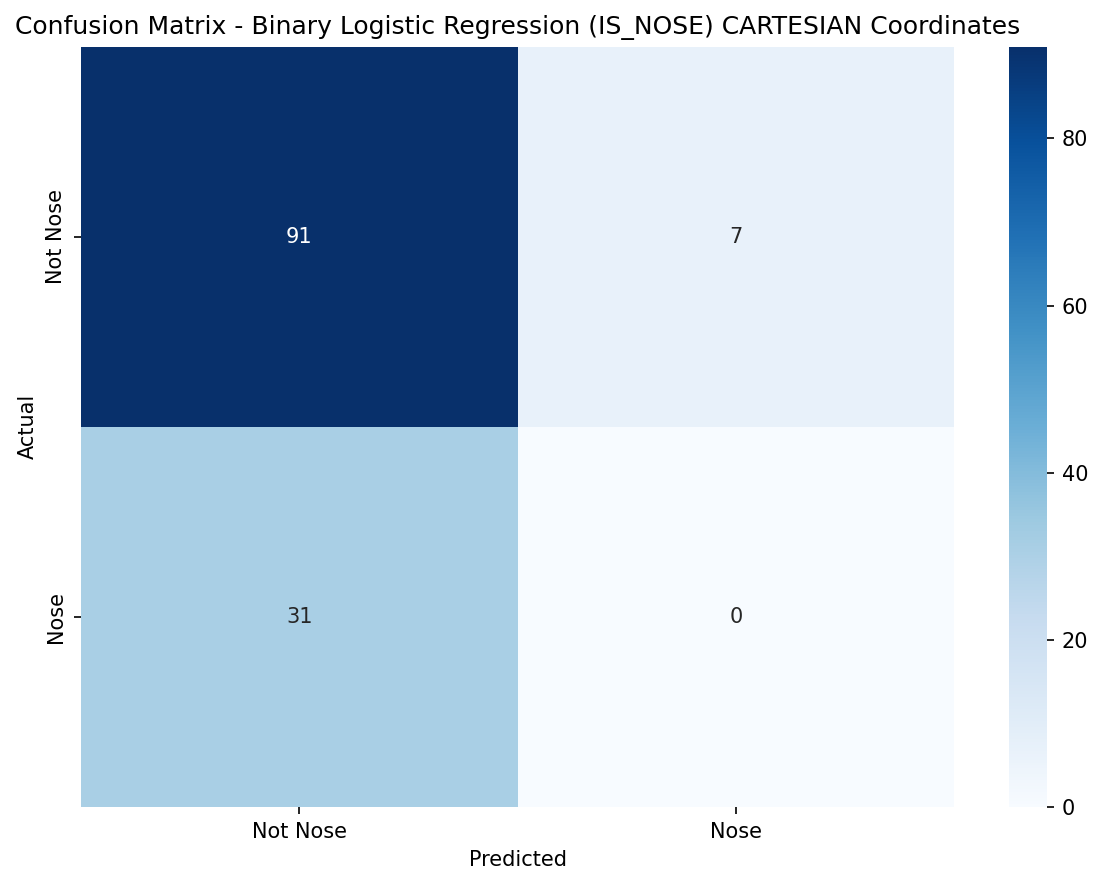

In [3]:
# Train a binary logistic regression model using horizontal and vertical coordinates to predict IS_NOSE
import statsmodels.api as sm

# Prepare the data
X = face[['horizontal', 'vertical']].copy()
y = face['IS_NOSE'].copy()

# Add constant term for intercept
X = sm.add_constant(X)

# Train the logistic regression model
logit_model = sm.Logit(y, X)
result_cartesian = logit_model.fit()

# Display model summary
print(result_cartesian.summary())

# Calculate odds ratios
print('\n' + '='*70)
print('ODDS RATIOS')
print('='*70)
odds_ratios = numpy.exp(result_cartesian.params)
print(odds_ratios)

# add model equation
print('\n' + '='*70)
print('MODEL EQUATION')
print('='*70)
print(f'log(p/(1-p)) = {result_cartesian.params["const"]:.6f} + {result_cartesian.params["horizontal"]:.6f}*horizontal + {result_cartesian.params["vertical"]:.6f}*vertical')   

# Get predicted probabilities and create predictions
print('\n' + '='*70)
print('CONFUSION MATRIX & MODEL PREDICTIONS')
print('='*70)
predicted_probs = result_cartesian.predict(X)
predicted_labels = (predicted_probs > 0.5).astype(int)

# Create confusion matrix
cm = pandas.crosstab(y, predicted_labels, rownames=['Actual'], colnames=['Predicted'], margins=True)
print("\nConfusion Matrix:")
print(cm)

# Calculate accuracy, sensitivity, specificity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y, predicted_labels).ravel()
accuracy = accuracy_score(y, predicted_labels)
sensitivity = recall_score(y, predicted_labels)  # True Positive Rate
specificity = tn / (tn + fp)  # True Negative Rate
precision = precision_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

print('\n' + '='*70)
print('MODEL PERFORMANCE METRICS')
print('='*70)
print(f'Accuracy:    {accuracy:.6f}')
print(f'Precision:   {precision:.6f}')
print(f'Sensitivity: {sensitivity:.6f} (True Positive Rate)')
print(f'Specificity: {specificity:.6f} (True Negative Rate)')
print(f'F1 Score:    {f1:.6f}')
print('='*70)

# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6), dpi=150)
cm_plot = confusion_matrix(y, predicted_labels)
import seaborn
seaborn.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Nose', 'Nose'], 
                yticklabels=['Not Nose', 'Nose'],
                cbar=True)
plt.title('Confusion Matrix - Binary Logistic Regression (IS_NOSE) CARTESIAN Coordinates')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


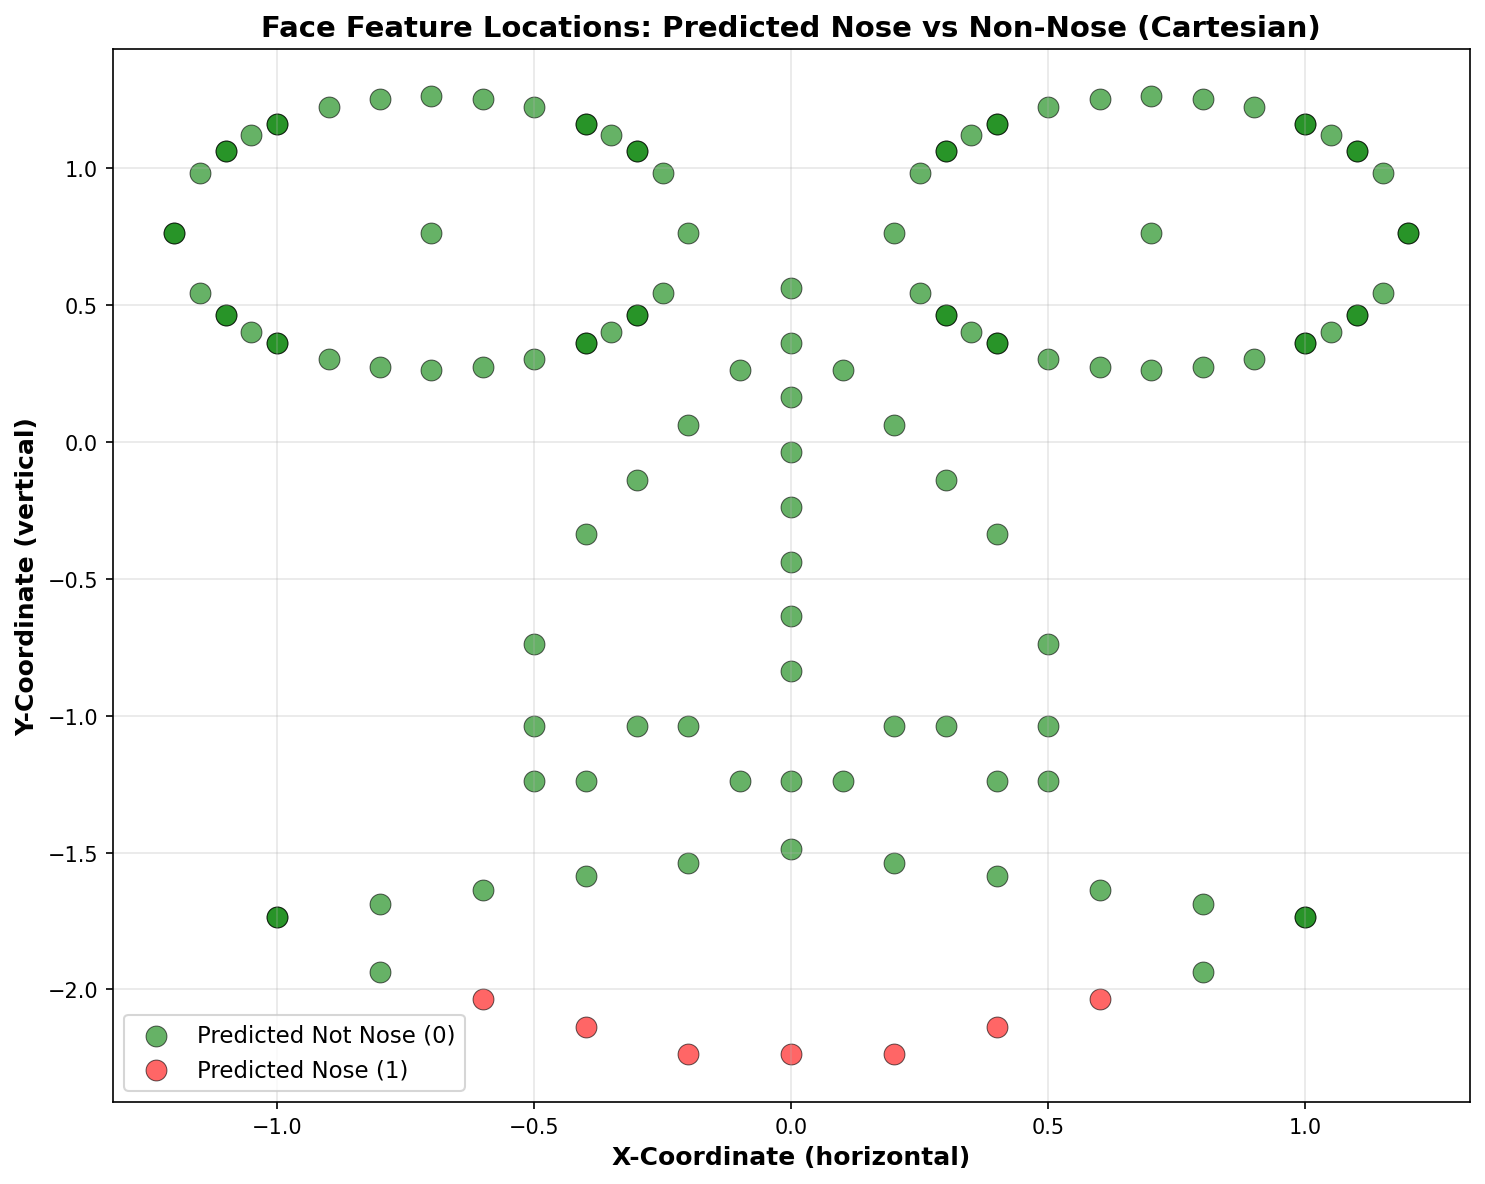

In [4]:
# Generate predictions from the logit model and plot with predicted IS_NOSE values
# Using predictions from the binary logistic regression model above

plt.figure(figsize=(10, 8), dpi=150)

# Plot points for each predicted class
for nose_class, color, label in [(0, 'green', 'Predicted Not Nose (0)'), (1, 'red', 'Predicted Nose (1)')]:
    mask = predicted_labels == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12, fontweight='bold')
plt.ylabel('Y-Coordinate (vertical)', fontsize=12, fontweight='bold')
plt.title('Face Feature Locations: Predicted Nose vs Non-Nose (Cartesian)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# Create a new model using polar coordinates
# Copy face dataframe to face_polar
face_polar = face.copy()


# Transform Cartesian coordinates to Polar coordinates
# r = sqrt((x + 0.2)^2 + y^2)
# theta = arctan(y / (x + 0.2)) with -π ≤ θ ≤ π

# Calculate r and theta
face_polar['r'] = numpy.sqrt((face_polar['horizontal'] + 0.2)**2 + face_polar['vertical']**2)
face_polar['theta'] = numpy.arctan2(face_polar['vertical'], face_polar['horizontal'] + 0.2)

# Drop the Cartesian coordinates (keep only polar coordinates and IS_NOSE)
face_polar = face_polar.drop(columns=['horizontal', 'vertical'])

# Display the transformed dataframe
face_polar

,IS_NOSE,r,theta
0,0,1.2578429950,2.4898233281
1,0,1.2578429950,2.4898233281
2,0,1.0942344356,2.6223331864
3,0,1.3670365760,2.3391242395
4,0,1.0121111599,2.6664563764
...,...,...,...
124,0,1.5881967762,-1.3161967021
125,0,1.6966346100,-1.2093352657
126,0,1.8220233259,-1.1162304514
127,0,1.9611142241,-1.0357112753


#### FACE DATA AND LOGIT REGRESSION

Optimization terminated successfully.
         Current function value: 0.093664
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                IS_NOSE   No. Observations:                  129
Model:                          Logit   Df Residuals:                      126
Method:                           MLE   Df Model:                            2
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.8301
Time:                        14:17:05   Log-Likelihood:                -12.083
converged:                       True   LL-Null:                       -71.135
Covariance Type:            nonrobust   LLR p-value:                 2.258e-26
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.9663      4.985      3.002      0.003       5.197      24.736
r            -16.8078      5

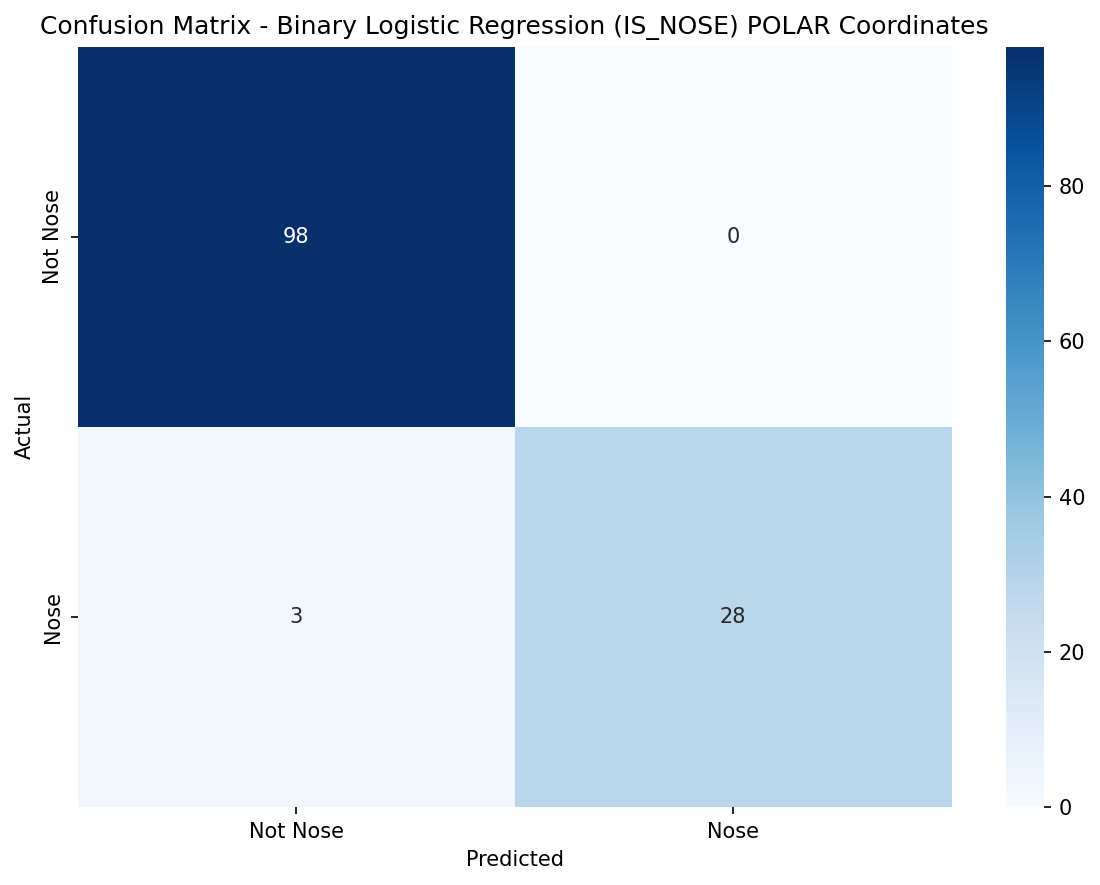

In [6]:
# Train a binary logistic regression model using horizontal and vertical coordinates to predict IS_NOSE
import statsmodels.api as sm

# Prepare the data
X = face_polar[['r', 'theta']].copy()
y = face['IS_NOSE'].copy()

# Add constant term for intercept
X = sm.add_constant(X)

# Train the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display model summary
print(result.summary())

# Calculate odds ratios
print('\n' + '='*70)
print('ODDS RATIOS')
print('='*70)
odds_ratios = numpy.exp(result.params)
print(odds_ratios)

# add model equation
print('\n' + '='*70)
print('MODEL EQUATION')
print('='*70)
print(f'log(p/(1-p)) = {result.params["const"]:.6f} + {result.params["r"]:.6f}*r + {result.params["theta"]:.6f}*theta')   

# Get predicted probabilities and create predictions
print('\n' + '='*70)
print('CONFUSION MATRIX & MODEL PREDICTIONS')
print('='*70)
predicted_probs = result.predict(X)
predicted_labels = (predicted_probs > 0.5).astype(int)

# Create confusion matrix
cm = pandas.crosstab(y, predicted_labels, rownames=['Actual'], colnames=['Predicted'], margins=True)
print("\nConfusion Matrix:")
print(cm)

# Calculate accuracy, sensitivity, specificity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y, predicted_labels).ravel()
accuracy = accuracy_score(y, predicted_labels)
sensitivity = recall_score(y, predicted_labels)  # True Positive Rate
specificity = tn / (tn + fp)  # True Negative Rate
precision = precision_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

print('\n' + '='*70)
print('MODEL PERFORMANCE METRICS')
print('='*70)
print(f'Accuracy:    {accuracy:.6f}')
print(f'Precision:   {precision:.6f}')
print(f'Sensitivity: {sensitivity:.6f} (True Positive Rate)')
print(f'Specificity: {specificity:.6f} (True Negative Rate)')
print(f'F1 Score:    {f1:.6f}')
print('='*70)

# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6), dpi=150)
cm_plot = confusion_matrix(y, predicted_labels)
import seaborn
seaborn.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Nose', 'Nose'], 
                yticklabels=['Not Nose', 'Nose'],
                cbar=True)
plt.title('Confusion Matrix - Binary Logistic Regression (IS_NOSE) POLAR Coordinates')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


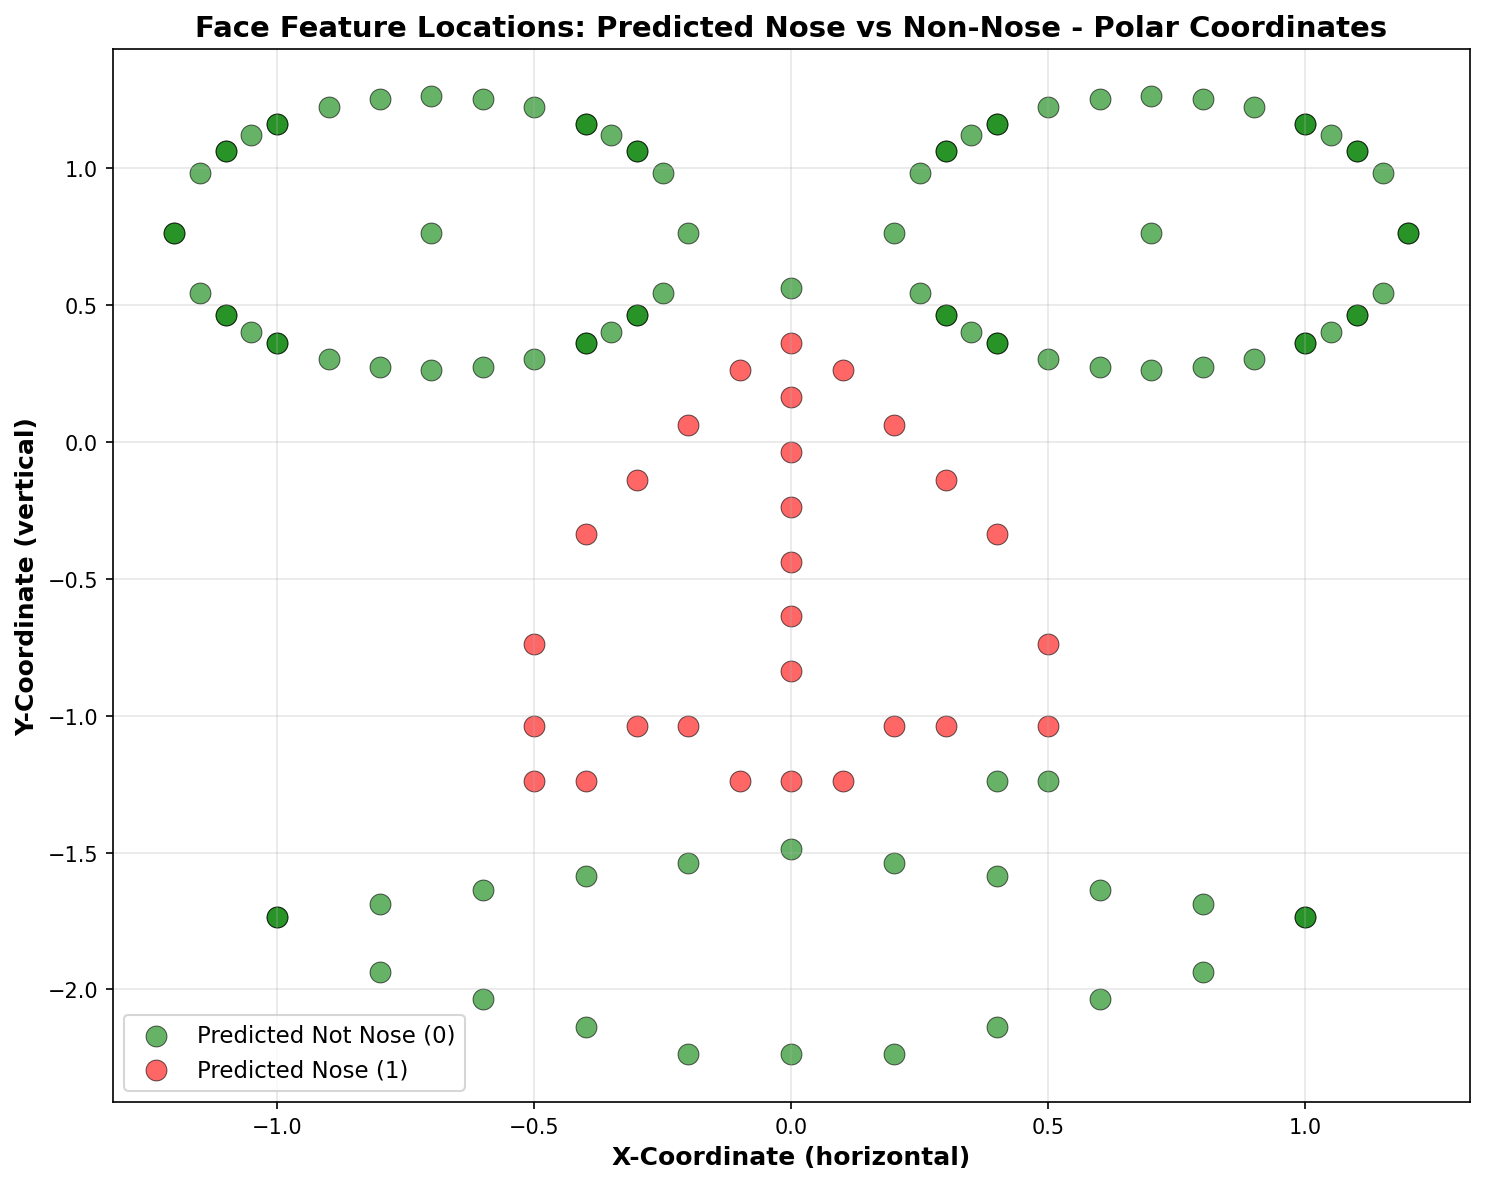

In [7]:
# Generate predictions from the logit model and plot with predicted IS_NOSE values
# Using predictions from the binary logistic regression model above

plt.figure(figsize=(10, 8), dpi=150)

# Plot points for each predicted class
for nose_class, color, label in [(0, 'green', 'Predicted Not Nose (0)'), (1, 'red', 'Predicted Nose (1)')]:
    mask = predicted_labels == nose_class
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=color, label=label, s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('X-Coordinate (horizontal)', fontsize=12, fontweight='bold')
plt.ylabel('Y-Coordinate (vertical)', fontsize=12, fontweight='bold')
plt.title('Face Feature Locations: Predicted Nose vs Non-Nose - Polar Coordinates', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
